In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay)

import joblib
from pathlib import Path

In [5]:
df = pd.read_csv("../data/processed/campuspulse_akgec_processed.csv")

print(df.shape)

(200000, 41)


In [6]:
drop_cols = [
    "complaint_id",
    "complaint_date",
    "complaint_time",
    "complaint_status",
    "response_time_hours",
    "resolution_time_hours",
    "maintenance_team",
    "resolution_type",
    "actual_expenditure"
    ]

df = df.drop(columns=drop_cols,errors="ignore")

print("Columns removed.")

Columns removed.


In [7]:
features = ["complainant_type", "department", "year_of_study", "campus_zone",
    "building", "floor", "room_lab_no", "facility_type", "class_section",
    "issue_category", "issue_subcategory", "severity", "affected_users",
    "issue_duration_hours", "previous_similar_complaints",
    "complaints_last_7_days", "complaints_last_30_days", "recurrence_count",
    "equipment_age_years", "infrastructure_age_years", "connectivity_impact",
    "safety_risk", "academic_impact", "operational_impact",
    "estimated_repair_cost", "weather_condition", "submission_channel",
    "complaint_month", "complaint_dayofweek", "complaint_year",
    "complaint_hour", "is_weekend", "time_period",
    "total_recent_complaints", "complaint_growth", "impact_score",
    "duration_per_user", "repair_cost_per_user",
    "equipment_infrastructure_age_gap", "operational_pressure"]

X = df[features].copy()
y = df["priority"].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (200000, 40)
Target: (200000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [9]:
print(X_train.shape)
print(X_test.shape)

(160000, 40)
(40000, 40)


In [10]:
preprocessor = joblib.load("../ml/models/classification/campuspulse_preprocessor.pkl")

pca = joblib.load("../ml/models/classification/campuspulse_pca.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_dense = (X_train_processed.toarray()
                 if hasattr(X_train_processed, "toarray")
                 else X_train_processed)
X_test_dense = (X_test_processed.toarray()
                if hasattr(X_test_processed, "toarray")
                else X_test_processed)

X_train_pca = pca.transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print("Before PCA:", X_train_dense.shape)
print("After PCA :", X_train_pca.shape)
print("Test PCA  :", X_test_pca.shape)

Before PCA: (160000, 304)
After PCA : (160000, 152)
Test PCA  : (40000, 152)


## Logistic Regression

In [11]:
lr_model = LogisticRegression(max_iter=2000,class_weight="balanced",random_state=42)

lr_model.fit(X_train_pca, y_train)

y_pred_lr = lr_model.predict(X_test_pca)

## Decision Tree

In [12]:
dt_model = DecisionTreeClassifier(class_weight="balanced",random_state=42)

In [13]:
dt_model.fit(X_train_dense,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

In [14]:
y_pred_dt = dt_model.predict(X_test_dense)

## Random Forest

In [15]:
rf_model = RandomForestClassifier(n_estimators=300,class_weight="balanced",n_jobs=-1,random_state=42)

In [16]:
rf_model.fit(X_train_dense,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [17]:
y_pred_rf = rf_model.predict(X_test_dense)

In [18]:
def evaluate_model(name, y_true, y_pred):
    return {"Model": name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average="weighted"),
            "Recall": recall_score(y_true, y_pred, average="weighted"),
             "F1": f1_score(y_true, y_pred, average="weighted")
             }

In [19]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr),
    evaluate_model("Decision Tree", y_test, y_pred_dt),
    evaluate_model("Random Forest", y_test, y_pred_rf)
])

results = results.sort_values("F1", ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.63700,0.648201,0.63700,0.637622
1,Logistic Regression,0.61920,0.635229,0.61920,0.606471
2,Decision Tree,0.51665,0.518587,0.51665,0.517555


In [20]:
lr_params = {"C": np.logspace(-3, 2, 10),
             "solver": ["lbfgs", "newton-cg"],
             "class_weight": ["balanced", None]
             }

lr_search = RandomizedSearchCV(LogisticRegression( max_iter=2000, random_state=42),
    param_distributions=lr_params,
    n_iter=10,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train_pca,y_train)

print("Best Logistic Regression parameters:")
print(lr_search.best_params_)

print("Best CV F1:",round(lr_search.best_score_, 4))

lr_best = lr_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Logistic Regression parameters:
{'solver': 'newton-cg', 'class_weight': None, 'C': np.float64(0.1668100537200059)}
Best CV F1: 0.6436


In [21]:
dt_params = {"criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 8, 12, 16, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", None]
}

dt_search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=15,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_search.fit(X_train_dense,y_train)

print("Best Decision Tree parameters:")
print(dt_search.best_params_)

print("Best CV F1:",round(dt_search.best_score_, 4))

dt_best = dt_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Decision Tree parameters:
{'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 30, 'criterion': 'entropy', 'class_weight': None}
Best CV F1: 0.5399


In [22]:
rf_params = {"n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1,random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_dense,y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("Best CV F1:",round(rf_search.best_score_, 4))

rf_best = rf_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced_subsample', 'bootstrap': False}
Best CV F1: 0.6412


In [23]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(y.value_counts(normalize=True).round(4))

Target distribution:
priority
Medium      70197
Low         68808
High        42242
Critical    18753
Name: count, dtype: int64

Target distribution (%):
priority
Medium      0.3510
Low         0.3440
High        0.2112
Critical    0.0938
Name: proportion, dtype: float64


In [24]:
print("Encoded features:", X_train_dense.shape)
print("PCA features:", X_train_pca.shape)

Encoded features: (160000, 304)
PCA features: (160000, 152)


In [25]:
y_pred_lr_tuned = lr_best.predict(X_test_pca)
y_pred_dt_tuned = dt_best.predict(X_test_dense)
y_pred_rf_tuned = rf_best.predict(X_test_dense)

In [26]:
tuned_results = pd.DataFrame([evaluate_model("Logistic Regression",y_test,y_pred_lr_tuned),
                              evaluate_model("Decision Tree",y_test,y_pred_dt_tuned),
                              evaluate_model("Random Forest",y_test,y_pred_rf_tuned)
                              ])

tuned_results = (tuned_results.sort_values("F1", ascending=False).reset_index(drop=True))

display(tuned_results)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.648350,0.670450,0.648350,0.647281
1,Random Forest,0.645275,0.659328,0.645275,0.645164
2,Decision Tree,0.538850,0.542724,0.538850,0.540514


In [27]:
comparison = pd.concat([results.assign(Stage="Baseline"),tuned_results.assign(Stage="Tuned")],ignore_index=True)

display(comparison.sort_values(["F1", "Accuracy"],ascending=False))

,Model,Accuracy,Precision,Recall,F1,Stage
3,Logistic Regression,0.648350,0.670450,0.648350,0.647281,Tuned
4,Random Forest,0.645275,0.659328,0.645275,0.645164,Tuned
0,Random Forest,0.637000,0.648201,0.637000,0.637622,Baseline
1,Logistic Regression,0.619200,0.635229,0.619200,0.606471,Baseline
5,Decision Tree,0.538850,0.542724,0.538850,0.540514,Tuned
2,Decision Tree,0.516650,0.518587,0.516650,0.517555,Baseline


In [28]:
predictions = {"Logistic Regression": y_pred_lr_tuned,"Decision Tree": y_pred_dt_tuned,"Random Forest": y_pred_rf_tuned}

for name, predictions_for_model in predictions.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(y_test,predictions_for_model))


Logistic Regression
              precision    recall  f1-score   support

    Critical       0.77      0.42      0.54      3751
        High       0.55      0.49      0.52      8448
         Low       0.82      0.69      0.75     13762
      Medium       0.57      0.76      0.65     14039

    accuracy                           0.65     40000
   macro avg       0.68      0.59      0.62     40000
weighted avg       0.67      0.65      0.65     40000


Decision Tree
              precision    recall  f1-score   support

    Critical       0.52      0.52      0.52      3751
        High       0.41      0.42      0.41      8448
         Low       0.68      0.64      0.66     13762
      Medium       0.50      0.52      0.51     14039

    accuracy                           0.54     40000
   macro avg       0.53      0.52      0.53     40000
weighted avg       0.54      0.54      0.54     40000


Random Forest
              precision    recall  f1-score   support

    Critical       0.64 

In [29]:
for name, predictions_for_model in predictions.items():

    report = classification_report(y_test,predictions_for_model,output_dict=True)

    print(f"{name}: " 
          f"Critical Recall = {report['Critical']['recall']:.3f}, "
          f"Critical F1 = {report['Critical']['f1-score']:.3f}")

Logistic Regression: Critical Recall = 0.422, Critical F1 = 0.545
Decision Tree: Critical Recall = 0.523, Critical F1 = 0.523
Random Forest: Critical Recall = 0.553, Critical F1 = 0.594


In [30]:
best_model_name = tuned_results.loc[tuned_results["F1"].idxmax(),"Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [31]:
model_map = {"Logistic Regression": lr_best,"Decision Tree": dt_best,"Random Forest": rf_best}

prediction_map = {"Logistic Regression": y_pred_lr_tuned,"Decision Tree": y_pred_dt_tuned,"Random Forest": y_pred_rf_tuned}

final_model = model_map[best_model_name]
best_pred = prediction_map[best_model_name]

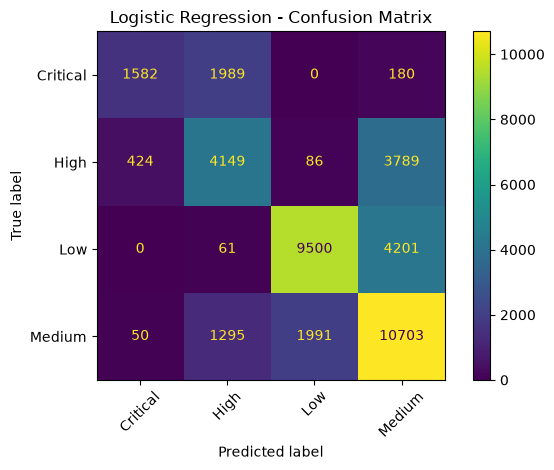

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test,best_pred,xticks_rotation=45)

plt.title(f"{best_model_name} - Confusion Matrix")

plt.tight_layout()
plt.show()

In [33]:
models_dir = Path("../ml/models/classification")

models_dir.mkdir(parents=True,exist_ok=True)

In [35]:
model_info = {
    "model": best_model_name,
    "metric": "weighted_f1",
    "f1_score": float(tuned_results.loc[tuned_results["Model"] == best_model_name, "F1"].iloc[0]),
    "accuracy": float(tuned_results.loc[tuned_results["Model"] == best_model_name, "Accuracy"].iloc[0]),
    "features": len(features),
    "train_size": len(X_train),
    "test_size": len(X_test)
}

joblib.dump(model_info, models_dir / "model_metadata.pkl")
print(model_info)

{'model': 'Logistic Regression', 'metric': 'weighted_f1', 'f1_score': 0.6472806271241331, 'accuracy': 0.64835, 'features': 40, 'train_size': 160000, 'test_size': 40000}


In [37]:
uses_pca = best_model_name == "Logistic Regression"

model_bundle = {
    "preprocessor": preprocessor,
    "pca": pca,
    "model": final_model,
    "model_name": best_model_name,
    "features": features,
    "uses_pca": uses_pca,
    "metadata": model_info
}

joblib.dump(model_bundle,models_dir / "priority_pipeline.pkl")

print("API model bundle exported successfully.")

API model bundle exported successfully.
